So it seems that I made a mistake in developing the perturbation theory for the system with multiple atoms.  I assumed that the total Hamiltonian could be expressed as $H = H_0 \otimes I + I \otimes H_1$ where $H_0=H_u+H_p$ for the first atom and $H_1=H_u+H_p$ for the second atom.  The problem is that $H_u$ and $H_p$ include the cavity mode, which means that this is essentially modeling two atoms interacting with two separate cavities.  I can't really see a way to rearrange things so that we could use a form like this.  To be a bit clearer, the problem is that there are terms like $a \sigma_{32}^\dag$, which is equivalent to $a \otimes \sigma_{32} \otimes I_1$.  This can't really be broken up in the way that we were doing before.

This file is for revising the multi atom theory to correct these issues.

In [1]:
import numpy as np
import qutip as qu
import matplotlib.pyplot as plt

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Functions

In [3]:
def gen_2lvl_Hp(num_atoms, coupling, detuning=0):
    """
    Function for calculating Hp for a system of two level atoms
    :param num_atoms: the number of atoms to consider
    :param coupling:  the coupling strength of each atom to the cavity mode
    :detuning:        the detuning between the cavity mode and the atomic transition frequency
    """
    # Create empty list for the rows of Hp
    Hp_list = []

    # Add rows for each atom - last entry corresponds to coupling the cavity mode to the atomic excitation; others are zero
    for i in range(num_atoms):
        temp = np.zeros(num_atoms+1)
        temp[-1] = coupling
        Hp_list.append(temp)

    # Add row that corresponds to the cavity field
    temp = coupling * np.ones(num_atoms+1)
    temp[-1] = detuning
    Hp_list.append(temp)

    # Return this as a Qobj for convenience
    return qu.Qobj(Hp_list)

In [4]:
def gen_3lvl_Hp(num_atoms, g10, g21, δc=0, Δ=0):
    """
    Function for generating the Hp for a system of 3 level atoms
    :param num_atoms:  the number of atoms to consider
    :param g10:        the coupling between |0> and |1> for each atom
    :param g21:        the copuling between |1> and |2> for each atom
    :param δc:         the detuning between the cavity mode and the |1>-|2> transition frequency
    :param Δ:          the detuning between the probe laser and the |0>-|1> transition frequency
    """
    # Create empty list for storing the rows of Hp
    Hp_list = []

    # Add rows corresponding to the cavity excitation being in the atom i.e. one atom is in state |2>
    for i in range(num_atoms):
        temp = np.zeros(num_atoms + 2 ** num_atoms)
        temp[i+num_atoms+1] = g21
    

In [5]:
def get_transmission_spectrum(δL, Hp, C_vec, κ, T0=1):
    """
    Function for calculating the transmission spectrum using the inverse approach
    :param δL:    the detuning between the control laser and the cavity mode
    :param Hp:    the Hamiltonian containing the single excitation terms
    :param C_vec: the vector |C> representing the cavity mode
    :param κ:     the cavity linewidth
    :param T0:    the base transmission coefficient of the cavity
    :returns:     the transmission spectrum
    """
    # Create the array for storing the transmission spectrum
    Ts = np.zeros(δL.shape[0])

    # Calculate the transmission terms
    for i in range(δL.shape[0]):
        temp = δL[i] * qu.qeye(Hp.dims[0]) - Hp
        temp_inv = temp.inv()
        Ts[i] = T0 * (κ / 2) ** 2 * np.abs(C_vec.dag() * temp_inv * C_vec) ** 2

    return Ts

### 2 Level Atoms
We'll start by considering a system of up to two two level atoms because they are simple enough that we can do things analytically.

In [6]:
# Define the atomic lowering operator
σm = qu.destroy(2)

# Define the cavity lowering operator
a = qu.destroy(2)

In [7]:
# Define our coupling parameter
g = 5
κ = 1
γ = 0.05

In [8]:
# Define the Hamiltonian at zero detuning
H_sa = -1j*κ * qu.tensor(a.dag() * a, qu.qeye(2)) - 1j*γ * qu.tensor(qu.qeye(2), σm.dag() * σm)
H_sa += g * (qu.tensor(a, σm.dag()) + qu.tensor(a.dag(), σm))
H_sa

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.+0.j   0.+0.j   0.+0.j   0.+0.j  ]
 [0.+0.j   0.-0.05j 5.+0.j   0.+0.j  ]
 [0.+0.j   5.+0.j   0.-1.j   0.+0.j  ]
 [0.+0.j   0.+0.j   0.+0.j   0.-1.05j]]

In [9]:
# Now define the Hamiltonian for two atoms
H_da = -1j*κ * qu.tensor([a.dag() * a, qu.qeye(2), qu.qeye(2)])
H_da += -1j*γ * qu.tensor([qu.qeye(2), σm.dag() * σm, qu.qeye(2)]) -1j*γ * qu.tensor([qu.qeye(2), qu.qeye(2), σm.dag() * σm])
H_da += g * (qu.tensor([a, σm.dag(), qu.qeye(2)]) + qu.tensor([a, qu.qeye(2), σm.dag()]))
H_da += g * (qu.tensor([a.dag(), σm, qu.qeye(2)]) + qu.tensor([a.dag(), qu.qeye(2), σm]))
H_da

Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j  ]
 [0.+0.j   0.-0.05j 0.+0.j   0.+0.j   5.+0.j   0.+0.j   0.+0.j   0.+0.j  ]
 [0.+0.j   0.+0.j   0.-0.05j 0.+0.j   5.+0.j   0.+0.j   0.+0.j   0.+0.j  ]
 [0.+0.j   0.+0.j   0.+0.j   0.-0.1j  0.+0.j   5.+0.j   5.+0.j   0.+0.j  ]
 [0.+0.j   5.+0.j   5.+0.j   0.+0.j   0.-1.j   0.+0.j   0.+0.j   0.+0.j  ]
 [0.+0.j   0.+0.j   0.+0.j   5.+0.j   0.+0.j   0.-1.05j 0.+0.j   0.+0.j  ]
 [0.+0.j   0.+0.j   0.+0.j   5.+0.j   0.+0.j   0.+0.j   0.-1.05j 0.+0.j  ]
 [0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j   0.-1.1j ]]

In [10]:
# Get the eigenvalues for the single atom H
sa_eigs = H_sa.eigenstates()
sa_eigs[0]

array([-4.97738636-0.525j,  0.        -1.05j ,  0.        +0.j   ,
        4.97738636-0.525j])

In [11]:
# Get the eigenstates for the double atom H
da_eigs = H_da.eigenstates()
da_eigs[0]

array([-7.05509568e+00-0.525j, -7.05509568e+00-0.575j,
       -6.60028401e-16-1.05j , -8.05814206e-17-0.05j ,
        0.00000000e+00-1.1j  ,  0.00000000e+00+0.j   ,
        7.05509568e+00-0.575j,  7.05509568e+00-0.525j])

In [12]:
# Is the difference between the differences scaled by \sqrt{2}?
print("SA Diff: ", sa_eigs[0][-1] - sa_eigs[0][0])
print("DA Diff: ", da_eigs[0][-1] - da_eigs[0][0])
print("Match? -> ", np.allclose(2*g*np.sqrt(2), da_eigs[0][-1] - da_eigs[0][0]))

SA Diff:  (9.95477272467835-2.220446049250313e-16j)
DA Diff:  (14.110191352352382+1.1102230246251565e-16j)
Match? ->  False


Now we want to test that this accurately captures the scaling that we expect, which is that the eigenvalues should have a separation $2\sqrt{N}g$ for $N$ atoms.  We can use the function for generating $H_p$ for 2 level atoms to generate a bunch, check the separation, and then plot that against the number of atoms.

In [13]:
# Define the basis vectors that we will need for constructing Hu and Hp
cav_bas = [qu.basis(2, i) for i in range(2)]
atom_bas = [qu.basis(2, i) for i in range(2)]

In [14]:
# Define a list for the basis of Hu
Hu_sa_bas = []

# Now loop over the atom basis vectors that are allowed
for i in range(1):
    Hu_sa_bas.append(qu.tensor([cav_bas[0], atom_bas[i]]))

In [15]:
# Now create a blank matrix whose elements we will calculate using the basis vectors and H_sa
Hu_sa = np.zeros((len(Hu_sa_bas), len(Hu_sa_bas)), dtype=complex)

# Now calculate the elements
for i in range(len(Hu_sa_bas)):
    for j in range(len(Hu_sa_bas)):
        Hu_sa[i][j] = Hu_sa_bas[i].dag() * H_sa * Hu_sa_bas[j]

# Finally convert to Qobj for convenience
Hu_sa = qu.Qobj(Hu_sa)
Hu_sa

Quantum object: dims=[[1], [1]], shape=(1, 1), type='scalar', dtype=Dense
Qobj data =
[[0.]]

In [16]:
# Define a list for the basis of Hp
Hp_sa_bas = []

# The first entry is just |0,2\rangle
Hp_sa_bas.append(qu.tensor([cav_bas[0], atom_bas[1]]))
Hp_sa_bas.append(qu.tensor([cav_bas[1], atom_bas[0]]))

In [17]:
# Now create a blank matrix for Hp
Hp_sa = np.zeros((len(Hp_sa_bas), len(Hp_sa_bas)), dtype=complex)

# And calculate the elements
for i in range(len(Hp_sa_bas)):
    for j in range(len(Hp_sa_bas)):
        Hp_sa[i][j] = Hp_sa_bas[i].dag() * H_sa * Hp_sa_bas[j]

# Convert to Qobj
Hp_sa = qu.Qobj(Hp_sa)
Hp_sa

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.-0.05j 5.+0.j  ]
 [5.+0.j   0.-1.j  ]]

In [18]:
# Define C
C = qu.Qobj([0,1])

In [19]:
# Define detuning array
δL = np.linspace(-20, 20, 100)

# Define blank array for transmission values
sa_Ts = np.zeros(δL.shape[0])

# Calculate transmission for each value of δL
for i in range(δL.shape[0]):
    temp = (δL[i]) * qu.qeye(Hp_sa.dims[0]) - Hp_sa
    temp_inv = temp.inv()
    sa_Ts[i] = (κ / 2) ** 2 * np.abs(C.dag() * temp_inv * C) ** 2

In [20]:
# Now repeat this for 2 atoms
Hu_da_bas = []

for i in range(1):
    Hu_da_bas.append(qu.tensor([cav_bas[0], atom_bas[i], atom_bas[i]]))

In [21]:
# Now create a blank matrix whose elements we will calculate using the basis vectors and H_sa
Hu_da = np.zeros((len(Hu_da_bas), len(Hu_da_bas)), dtype=complex)

# Now calculate the elements
for i in range(len(Hu_da_bas)):
    for j in range(len(Hu_da_bas)):
        Hu_da[i][j] = Hu_da_bas[i].dag() * H_da * Hu_da_bas[j]

# Finally convert to Qobj for convenience
Hu_da = qu.Qobj(Hu_da)
Hu_da

Quantum object: dims=[[1], [1]], shape=(1, 1), type='scalar', dtype=Dense
Qobj data =
[[0.]]

In [22]:
# Define a list for the basis of Hp
Hp_da_bas = []

# The first entry is just |0,2\rangle
Hp_da_bas.append(qu.tensor([cav_bas[0], atom_bas[0], atom_bas[1]]))
Hp_da_bas.append(qu.tensor([cav_bas[0], atom_bas[1], atom_bas[0]]))
Hp_da_bas.append(qu.tensor([cav_bas[1], atom_bas[0], atom_bas[0]]))

In [23]:
# Now create a blank matrix for Hp
Hp_da = np.zeros((len(Hp_da_bas), len(Hp_da_bas)), dtype=complex)

# And calculate the elements
for i in range(len(Hp_da_bas)):
    for j in range(len(Hp_da_bas)):
        Hp_da[i][j] = Hp_da_bas[i].dag() * H_da * Hp_da_bas[j]

# Convert to Qobj
Hp_da = qu.Qobj(Hp_da)
Hp_da

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.-0.05j 0.+0.j   5.+0.j  ]
 [0.+0.j   0.-0.05j 5.+0.j  ]
 [5.+0.j   5.+0.j   0.-1.j  ]]

In [24]:
# Define C
C = qu.Qobj([0,0,1])

In [25]:
# Define blank array for transmission values
da_Ts = np.zeros(δL.shape[0])

# Calculate transmission for each value of δL
for i in range(δL.shape[0]):
    temp = (δL[i]) * qu.qeye(Hp_da.dims[0]) - Hp_da
    temp_inv = temp.inv()
    da_Ts[i] = (κ / 2) ** 2 * np.abs(C.dag() * temp_inv * C) ** 2

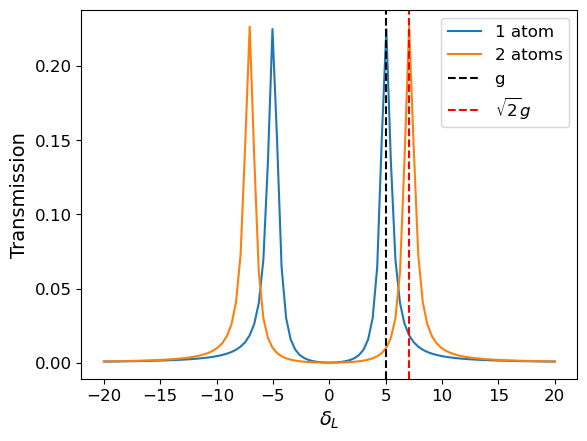

In [26]:
# Now plot the results
plt.plot(δL, sa_Ts, label='1 atom')
plt.plot(δL, da_Ts, label='2 atoms')
plt.axvline(x=g, color='k', linestyle='--', label='g')
plt.axvline(x=np.sqrt(2)*g, color='r', linestyle='--', label='$\\sqrt{2}g$')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()
plt.savefig("transmission_spectrum_2lvl_atom_splitting.png", dpi=300, format='png')

In [27]:
# Define the number of atoms that we want to consider
num_atoms = np.arange(1, 11)

In [28]:
# Create array for storing eigenvalue separations
eig_vals_sep = np.zeros(num_atoms.shape[0])

# For each number of atoms, generate the Hp, calculate the difference of the eigenvalues and store
for i in range(num_atoms.shape[0]):
    temp_Hp = gen_2lvl_Hp(num_atoms[i], g)
    eig_vals_sep[i] = temp_Hp.eigenstates()[0][-1] - temp_Hp.eigenstates()[0][0]

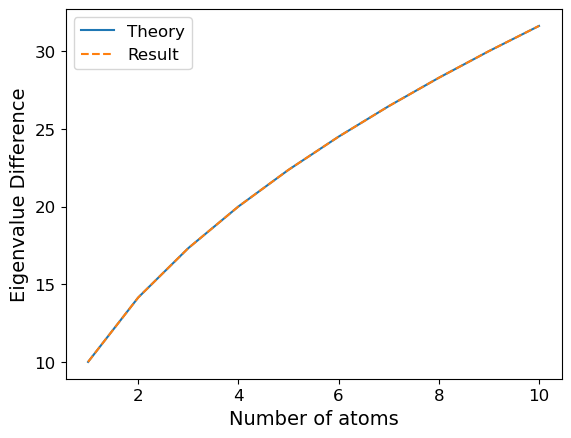

In [29]:
# Plot the differences
plt.plot(num_atoms, 2*np.sqrt(num_atoms)*g, label='Theory')
plt.plot(num_atoms, eig_vals_sep, '--', label='Result')
plt.xlabel("Number of atoms")
plt.ylabel("Eigenvalue Difference")
plt.legend()

Now we just want to confirm that the transmission spectra also show this scaling.

In [30]:
# Define the detuning array
δL = np.linspace(-20, 20, 100)

In [31]:
# Now calculate transmission spectra for the first and last number of atoms - we're skipping the others to avoid clutter
Ts = np.zeros((2, δL.shape[0]))
for i, _ in enumerate([1, 10]):
    temp_Hp = gen_2lvl_Hp(_, g)
    Ts[i] = get_transmission_spectrum(δL, temp_Hp, qu.basis(_+1, _), 1)

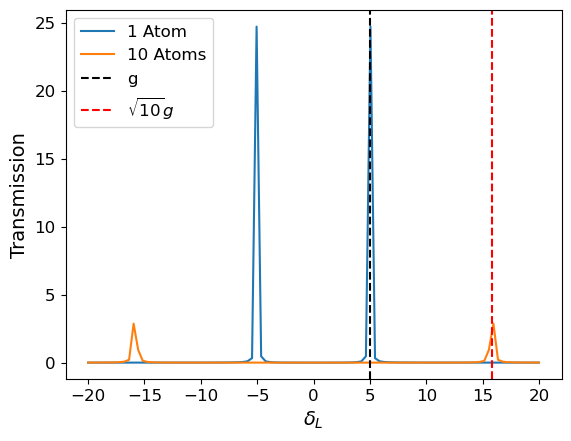

In [32]:
plt.plot(δL, Ts[0], label='1 Atom')
plt.plot(δL, Ts[1], label='10 Atoms')
plt.axvline(x=g, color='k', linestyle='--', label='g')
plt.axvline(x=np.sqrt(10)*g, color='r', linestyle='--', label='$\\sqrt{10}g$')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()

### 3 Level Atoms
Now we'll look at systems of atoms with 3 levels.  We'll start by considering the separation in eigenvalues for 2 atoms to confirm that it is something like $2\sqrt{2}\sqrt{g_{10}^2 + g_{21}^2}$.

In [80]:
# Let's start by defining the parameters - we'll assume all detunings are 0 for simplicity for now
g10 = 10
g21 = 1
κ = 1
γ10 = 1
γ21 = 0.05

In [81]:
# Now define the operators that we'll be using
σ10 = qu.Qobj([[0, 1, 0],
               [0, 0, 0],
               [0, 0, 0]])
σ21 = qu.Qobj([[0, 0, 0],
               [0, 0, 1],
               [0, 0, 0]])
a = qu.destroy(2)

# Also define the identity operators for ease of use
Ic = qu.qeye(2)
I0 = qu.qeye(3)
I1 = qu.qeye(3)

In [82]:
# Now define the Hamiltonian - the detunings are 0
H_da = -1j*κ * qu.tensor([a.dag() * a, I0, I1])
H_da += -1j*γ10 * (qu.tensor([Ic, σ10.dag() * σ10, I1]) + qu.tensor([Ic, I0, σ10.dag() * σ10]))
H_da += -1j*γ21 * (qu.tensor([Ic, σ21.dag() * σ21, I1]) + qu.tensor([Ic, I0, σ21.dag() * σ21]))
H_da += g10 * (qu.tensor([Ic, σ10.dag(), I1]) + qu.tensor([Ic, σ10, I1]) + qu.tensor([Ic, I0, σ10.dag()]) + qu.tensor([Ic, I0, σ10]))
H_da += g21 * (qu.tensor([a, σ21.dag(), I1]) + qu.tensor([a, I0, σ21.dag()]) + qu.tensor([a.dag(), σ21, I1]) + qu.tensor([a.dag(), I0, σ21]))
H_da.eigenstates()[0]

array([-2.00730791e+01-1.99091462j, -1.99749844e+01-1.j        ,
       -1.00858173e+01-1.54084776j, -1.00367658e+01-0.55461946j,
       -9.98749218e+00-1.55j      , -9.93890670e+00-0.56377428j,
        0.00000000e+00-1.1j       ,  0.00000000e+00-1.j        ,
        2.15154151e-16-1.99076107j,  2.22044805e-16-1.9906222j ,
        2.39391840e-16-0.11830448j,  5.28121136e-15-1.j        ,
        9.93890670e+00-0.56377428j,  9.98749218e+00-1.55j      ,
        1.00367658e+01-0.55461946j,  1.00858173e+01-1.54084776j,
        1.99749844e+01-1.j        ,  2.00730791e+01-1.99091462j])

In [83]:
print("Difference between first and last eigenvalues: ", H_da.eigenstates()[0][-1] - H_da.eigenstates()[0][0])
print("Difference between second and second last eigenvalues: ", H_da.eigenstates()[0][-2] - H_da.eigenstates()[0][1])
print("Expected difference: ", 2*np.sqrt(2)*np.sqrt(g10 ** 2 + g21 ** 2))

Difference between first and last eigenvalues:  (40.14615819300842+7.993605777301127e-15j)
Difference between second and second last eigenvalues:  (39.94996871087636-2.220446049250313e-16j)
Expected difference:  28.42534080710379


In [84]:
H_sa = -1j*κ * qu.tensor([a.dag() * a, I0])
H_sa += -1j*γ10 * qu.tensor([Ic, σ10.dag() * σ10])
H_sa += -1j*γ21 * qu.tensor([Ic, σ21.dag() * σ21])
H_sa += g10 * (qu.tensor([Ic, σ10.dag()]) + qu.tensor([Ic, σ10]))
H_sa += g21 * (qu.tensor([a, σ21.dag()]) + qu.tensor([a.dag(), σ21]))
H_sa

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0.+0.j   10.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [10.+0.j    0.-1.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.-0.05j  0.+0.j    1.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.-1.j   10.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    1.+0.j   10.+0.j    0.-2.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.-1.05j]]

In [85]:
print("Difference between first and last eigenvalues: ", H_sa.eigenstates()[0][-1] - H_sa.eigenstates()[0][0])
print("Expected difference: ", 2*np.sqrt(g10 ** 2 + g21 ** 2))

Difference between first and last eigenvalues:  (20.0735315850544-1.1102230246251565e-15j)
Expected difference:  20.09975124224178


So, we don't see the scaling on the first and last eigenvalues that we expected.  But we do see the scaling on the difference between the second to last and second eigenvalues.  This seems strange, but I'm not really sure what the first and last eigenvalues are supposed to look like anyway.  They might even correspond to states that we don't care about because they aren't really possible in our system (i.e. they're from states that have two cavity excitations for example).

In [86]:
# Define the basis vectors that we will need for constructing Hu and Hp
cav_bas = [qu.basis(2, i) for i in range(2)]
atom_bas = [qu.basis(3, i) for i in range(3)]

We'll elect to handle the single atom case first.  We define $H_u$ over the space $\{|0, 0\rangle, |0, 1\rangle\}$ and $H_p$ over the space $\{|0, 2\rangle, |1, 0\rangle, |1, 1\rangle\}$

In [87]:
# Define a list for the basis of Hu
Hu_sa_bas = []

# Now loop over the atom basis vectors that are allowed
for i in range(2):
    Hu_sa_bas.append(qu.tensor([cav_bas[0], atom_bas[i]]))

In [88]:
# Now create a blank matrix whose elements we will calculate using the basis vectors and H_sa
Hu_sa = np.zeros((len(Hu_sa_bas), len(Hu_sa_bas)), dtype=complex)

# Now calculate the elements
for i in range(len(Hu_sa_bas)):
    for j in range(len(Hu_sa_bas)):
        Hu_sa[i][j] = Hu_sa_bas[i].dag() * H_sa * Hu_sa_bas[j]

# Finally convert to Qobj for convenience
Hu_sa = qu.Qobj(Hu_sa)
Hu_sa

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.+0.j 10.+0.j]
 [10.+0.j  0.-1.j]]

In [89]:
# Define a list for the basis of Hp
Hp_sa_bas = []

# The first entry is just |0,2\rangle
Hp_sa_bas.append(qu.tensor([cav_bas[0], atom_bas[2]]))

# Now loop over the atom states that are allowed
for i in range(2):
    Hp_sa_bas.append(qu.tensor([cav_bas[1], atom_bas[i]]))

In [90]:
# Now create a blank matrix for Hp
Hp_sa = np.zeros((len(Hp_sa_bas), len(Hp_sa_bas)), dtype=complex)

# And calculate the elements
for i in range(len(Hp_sa_bas)):
    for j in range(len(Hp_sa_bas)):
        Hp_sa[i][j] = Hp_sa_bas[i].dag() * H_sa * Hp_sa_bas[j]

# Convert to Qobj
Hp_sa = qu.Qobj(Hp_sa)
Hp_sa

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.-0.05j  0.+0.j    1.+0.j  ]
 [ 0.+0.j    0.-1.j   10.+0.j  ]
 [ 1.+0.j   10.+0.j    0.-2.j  ]]

In [91]:
Hp_sa_eigs = Hp_sa.eigenstates()
Hp_sa_eigs

(array([-1.00367658e+01-1.49538054j, -3.76434994e-16-0.05923893j,
         1.00367658e+01-1.49538054j]),
 array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.06902028+0.00993951j]
         [-0.70280449+0.03468803j]
         [ 0.70710678+0.j        ]]                                           ,
        Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 9.95170236e-01+0.00000000e+00j]
         [-9.77326286e-02-3.12250226e-17j]
         [-1.09504419e-16-9.19430525e-03j]]                                   ,
        Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.06902028+0.00993951j]
         [0.70280449+0.03468803j]
         [0.70710678+0.j        ]]                                            ],
       dtype=object))

In [110]:
# Now let's define our |C>
# First get eigenstates of Hu_sa
Hu_sa_eigs = Hu_sa.eigenstates()
q = Hu_sa_eigs
q

(array([-9.98749218-0.5j,  9.98749218-0.5j]),
 array([Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.70622234+0.03535534j]
         [ 0.70710678+0.j        ]]                                           ,
        Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.70710678+0.j        ]
         [0.70622234-0.03535534j]]                                            ],
       dtype=object))

Now the basis of $|q\rangle$ is $|0, 0\rangle$ and $|0, 1\rangle$ from top to bottom.  Applying $V$ to this to get $|C\rangle$ means that these states become $|1,0\rangle$ and $|1,1\rangle$ respectively.  So then we should have $|C\rangle = (0, c0, c1)^T$ in $H_p$, where the $c_i$ are the coefficients of the eigenstates of $H_u$ that we want to perturb.

In [140]:
# Create blank vector for C
Ca = np.zeros(len(Hp_sa_bas), dtype=complex)
Cb = np.zeros(len(Hp_sa_bas), dtype=complex)
for i in range(len(Hu_sa_bas)):
    Ca[i+1] = q[1][0].full().T[0][i] #+ q[1][1].full().T[0][i]
    Cb[i+1] = q[1][1].full().T[0][i] #-q[1][0].full().T[0][i] 

# Now turn it into a Qobj
Ca = qu.Qobj(Ca)
Ca /= np.sqrt(Ca.dag() * Ca)
Cb = qu.Qobj(Cb)
Cb /= np.sqrt(Cb.dag() * Cb)
Cc = qu.Qobj([1,0,0])
Cb

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[0.        +0.j        ]
 [0.70710678+0.j        ]
 [0.70622234-0.03535534j]]

In [141]:
# Define detuning array
δL = np.linspace(-20, 20, 100)

# Define blank array for transmission values
sa_Ts_a = np.zeros(δL.shape[0])
sa_Ts_b = np.zeros(δL.shape[0])
sa_Ts_c = np.zeros(δL.shape[0])

# Calculate transmission for each value of δL
for i in range(δL.shape[0]):
    temp_a = (δL[i] + Hu_sa_eigs[0][0]) * qu.qeye(Hp_sa.dims[0]) - Hp_sa
    temp_b = (δL[i] + Hu_sa_eigs[0][1]) * qu.qeye(Hp_sa.dims[0]) - Hp_sa
    tempa_inv = temp_a.inv()
    tempb_inv = temp_b.inv()
    sa_Ts_a[i] = (κ / 2) ** 2 * np.abs(Ca.dag() * tempa_inv * Ca) ** 2
    sa_Ts_b[i] = (κ / 2) ** 2 * np.abs(Cb.dag() * tempb_inv * Cb) ** 2
    sa_Ts_c[i] = (κ / 2) ** 2 * np.abs(Cc.dag() * tempb_inv * Cc) ** 2

In [142]:
δL[0] * qu.qeye(Hp_sa.dims[0]) - Hp_sa

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-20.+0.05j   0.+0.j    -1.+0.j  ]
 [  0.+0.j   -20.+1.j   -10.+0.j  ]
 [ -1.+0.j   -10.+0.j   -20.+2.j  ]]

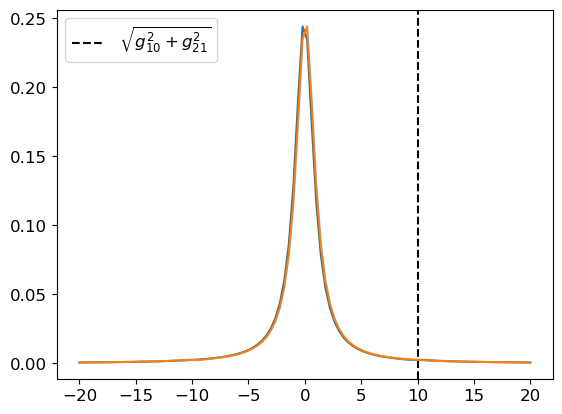

In [143]:
plt.plot(δL, sa_Ts_a)
plt.axvline(x=np.sqrt(g10**2 + g21**2), color='k', linestyle='--', label='$\\sqrt{g_{10}^2+g_{21}^2}$')
plt.plot(δL, sa_Ts_b)
#plt.plot(δL, sa_Ts_c)
plt.legend()

In [98]:
num_atoms = 2

# Define the allowed basis vectors respecting the ordering we've been using
cav_bas_0 = qu.basis(2, 0)
cav_bas_1 = qu.basis(2, 1)
atom_bas_0 = qu.basis(3, 0)
atom_bas_1 = qu.basis(3, 1)
atom_bas_2 = qu.basis(3, 2)

# Create list for storing the tensored allowed basis
Hp_bas = []

# first consider the basis with only 1 atom in |2>
temp_list = [atom_bas_0 for _ in range(num_atoms)]
temp_list.insert(0, cav_bas_0)
for i in range(num_atoms):
    temp_copy = temp_list.copy()
    temp_copy[i+1] = atom_bas_2
    Hp_bas.append(qu.tensor(temp_copy))

temp_list = [atom_bas_1 for _ in range(num_atoms)]
temp_list.insert(0, cav_bas_0)
for i in range(num_atoms):
    temp_copy = temp_list.copy()
    temp_copy[i+1] = atom_bas_2
    Hp_bas.append(qu.tensor(temp_copy))

# Now consider the basis terms with no atoms in |2> but the cavity in |1>
atom_bas_list = [atom_bas_0, atom_bas_1]
for i in range(num_atoms):
    for j in range(num_atoms):
        temp_list = [cav_bas_1, atom_bas_list[i], atom_bas_list[j]]
        Hp_bas.append(qu.tensor(temp_list))

In [99]:
# Let's try and see if we can get Hp by applying these basis vectors to H
Hp_da = np.zeros((len(Hp_bas), len(Hp_bas)), dtype=complex)
for i in range(len(Hp_bas)):
    for j in range(len(Hp_bas)):
        Hp_da[i][j] = Hp_bas[i].dag() * H_da * Hp_bas[j]
Hp_da = qu.Qobj(Hp_da)
Hp_da

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.-0.05j  0.+0.j   10.+0.j    0.+0.j    0.+0.j    0.+0.j    1.+0.j
   0.+0.j  ]
 [ 0.+0.j    0.-0.05j  0.+0.j   10.+0.j    0.+0.j    1.+0.j    0.+0.j
   0.+0.j  ]
 [10.+0.j    0.+0.j    0.-1.05j  0.+0.j    0.+0.j    0.+0.j    0.+0.j
   1.+0.j  ]
 [ 0.+0.j   10.+0.j    0.+0.j    0.-1.05j  0.+0.j    0.+0.j    0.+0.j
   1.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.-1.j   10.+0.j   10.+0.j
   0.+0.j  ]
 [ 0.+0.j    1.+0.j    0.+0.j    0.+0.j   10.+0.j    0.-2.j    0.+0.j
  10.+0.j  ]
 [ 1.+0.j    0.+0.j    0.+0.j    0.+0.j   10.+0.j    0.+0.j    0.-2.j
  10.+0.j  ]
 [ 0.+0.j    0.+0.j    1.+0.j    1.+0.j    0.+0.j   10.+0.j   10.+0.j
   0.-3.j  ]]

In [100]:
Hp_da_eigs = Hp_da.eigenstates()
Hp_da_eigs

(array([-2.00730791e+01-1.99091462j, -1.00367658e+01-0.55461946j,
        -9.93890670e+00-0.56377428j, -2.73477681e-20-1.9906222j ,
         7.62932077e-17-1.99076107j,  9.93890670e+00-0.56377428j,
         1.00367658e+01-0.55461946j,  2.00730791e+01-1.99091462j]),
 array([Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.04802607-0.00930938j]
         [ 0.04802607-0.00930938j]
         [-0.04851121+0.00691168j]
         [-0.04851121+0.00691168j]
         [ 0.49277072-0.04877304j]
         [-0.49698777+0.02453657j]
         [-0.49698777+0.02453657j]
         [ 0.50001187+0.j        ]]                                           ,
        Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 5.00000000e-01+0.00000000e+00j]
         [-5.00000000e-01+4.12170298e-15j]
         [-4.96957819e-01-2.45281434e-02j]
         [ 4.96957819e-01+2.45281434e-02j]
         [-6.02886614e-15-2.76289271e-1

In [101]:
# Now do the same thing for Hu
Hu_bas = []
for i in range(num_atoms):
    for j in range(num_atoms):
        temp_list = [cav_bas_0, atom_bas_list[i], atom_bas_list[j]]
        Hu_bas.append(qu.tensor(temp_list))

In [102]:
Hu = np.zeros((len(Hu_bas), len(Hu_bas)), dtype=complex)
for i in range(len(Hu_bas)):
    for j in range(len(Hu_bas)):
        Hu[i][j] = Hu_bas[i].dag() * H_da * Hu_bas[j]
Hu = qu.Qobj(Hu)
Hu

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.+0.j 10.+0.j 10.+0.j  0.+0.j]
 [10.+0.j  0.-1.j  0.+0.j 10.+0.j]
 [10.+0.j  0.+0.j  0.-1.j 10.+0.j]
 [ 0.+0.j 10.+0.j 10.+0.j  0.-2.j]]

In [103]:
# Get eigenstates of Hu so we can select one for perturbation
Hu_eigs = Hu.eigenstates()
Hu_eigs

(array([-1.99749844e+01-1.j,  0.00000000e+00-1.j,  5.28121136e-15-1.j,
         1.99749844e+01-1.j]),
 array([Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.49937461+0.025j]
         [ 0.5       +0.j   ]
         [ 0.5       +0.j   ]
         [-0.49937461-0.025j]]                                                ,
        Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.00071356+1.50044018e-04j]
         [-0.7070989 -7.13564396e-05j]
         [ 0.70711391+0.00000000e+00j]
         [-0.00071356-1.50044018e-04j]]                                       ,
        Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[-7.06224552e-01+2.77555756e-17j]
         [ 3.46944695e-17+3.53112276e-02j]
         [ 3.44776291e-17+3.53112276e-02j]
         [ 7.06224552e-01+0.00000000e+00j]]                                   ,
        Quantum object: d

In [104]:
# Let's pick the second
q = Hu_eigs[1][1]
q

Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.00071356+1.50044018e-04j]
 [-0.7070989 -7.13564396e-05j]
 [ 0.70711391+0.00000000e+00j]
 [-0.00071356-1.50044018e-04j]]

From top to bottom, the states are $|0, 0, 0\rangle, |0, 0, 1\rangle, |0, 1, 0\rangle$, and $|0, 1, 1\rangle$.  Applying $V$ to this state should transform these to $|1, 0, 0\rangle, |1, 0, 1\rangle, |1, 1, 0\rangle$, and $|1, 1, 1\rangle$.  In the basis of $H_p$, this corresponds to the last four entries in the column vector.  So $|C\rangle = (0, 0, c0, c1, c2, c3)^T$, where $c_i$ are the coefficients of the eigenstate of $H_u$ that we want to perturb.

In [117]:
C = np.zeros(len(Hp_bas), dtype=complex)
C = qu.Qobj([0,0,0,0,1,0,0,0])
#C = qu.Qobj([0,0,0,0,0,1,0,0])
#q = Hu_eigs[1][0] + Hu_eigs[1][1] + Hu_eigs[1][2] + Hu_eigs[1][3]
#q /= np.sqrt(q.dag() * q)
#for i in range(len(Hu_bas)):
#    C[i+4] = q.full().T[0][i]
#C = qu.Qobj(C)
C

Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]]

In [118]:
# Define the detuning array
δL = np.linspace(-20, 20, 100)

In [119]:
da_Ts = np.zeros(δL.shape[0])
for i in range(δL.shape[0]):
    temp = δL[i] * qu.qeye(Hp_da.dims[0]) - Hp_da
    temp_inv = temp.inv()
    da_Ts[i] = (κ / 2) ** 2 * np.abs(C.dag() * temp_inv * C) ** 2

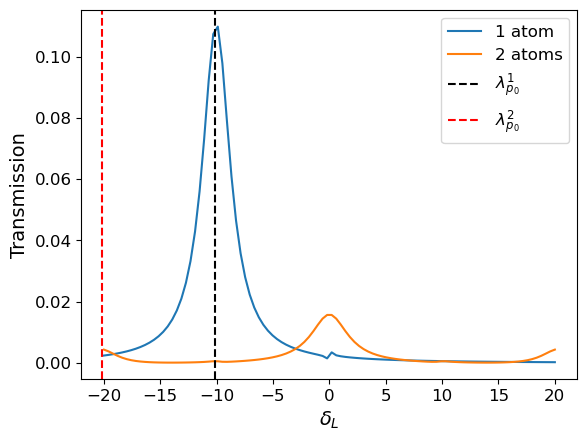

In [120]:
plt.plot(δL, sa_Ts_a, label='1 atom')
plt.plot(δL, da_Ts, label='2 atoms')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.axvline(x=-np.abs(Hp_sa_eigs[0][0]), color='k', linestyle='--', label='$\\lambda^1_{p_0}$')
plt.axvline(x=-np.abs(Hp_da_eigs[0][0]), color='r', linestyle='--', label='$\\lambda^2_{p_0}$')
plt.legend()

In [110]:
Hp_da_eigs = Hp_da.eigenstates()
Hp_da_eigs

(array([-1.11157255e+01-1.80628334j, -4.90401621e+00-1.025j     ,
        -1.43519512e-18-0.31723226j,  6.84172816e-17-2.12020107j,
         4.90401621e+00-1.025j     ,  1.11157255e+01-1.80628334j]),
 array([Quantum object: dims=[[6], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.21942878+3.46697225e-02j]
         [-0.21942878+3.46697225e-02j]
         [-0.44745894+3.24566029e-02j]
         [ 0.5       -2.77555756e-17j]
         [ 0.5       +0.00000000e+00j]
         [-0.44468483-4.77546593e-02j]]                                       ,
        Quantum object: dims=[[6], [1]], shape=(6, 1), type='ket', dtype=Dense
        Qobj data =
        [[-5.00000000e-01+3.46944695e-17j]
         [ 5.00000000e-01+0.00000000e+00j]
         [ 1.50711037e-16-2.31468836e-17j]
         [-4.90401621e-01-9.75000000e-02j]
         [ 4.90401621e-01+9.75000000e-02j]
         [ 1.72738731e-16+1.81118335e-17j]]                                   ,
        Quantum object: dims=[[6

In [115]:
np.abs(Hp_sa_eigs[0][0])*np.sqrt(2)

np.float64(10.083430888635862)

In [116]:
np.sqrt(g10**2+g21**2)*np.sqrt(2)

np.float64(10.000000000000002)